# Ensamblado de Modelos: Bagging y Boosting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/08_ensamblado_de_modelos.ipynb)

## Objetivos


- Comprender la filosofía del ensamblado: por qué la "sabiduría de las multitudes" supera a un modelo individual.
- Diferenciar matemáticamente entre **Bagging** (reducción de varianza) y **Boosting** (reducción de sesgo).
- Implementar y comparar *Random Forest* y *Gradient Boosting* en un escenario real con desbalance de clases severo.



## Prerrequisitos


- Entendimiento profundo de los Árboles de Decisión y su problema de alta varianza.
- Haber completado: [Clasificación: Árboles de Decisión y Reglas Lógicas](04_clasificacion_arboles_y_reglas.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica



En el Notebook [Clasificación: Árboles de Decisión y Reglas Lógicas](04_clasificacion_arboles_y_reglas.ipynb) vimos que un Árbol de Decisión es muy interpretable, pero sufre de **Alta Varianza**: si cambian un poco los datos de entrenamiento, el árbol cambia drásticamente. Tiende a memorizar el ruido (*Overfitting*).

¿Cómo solucionamos esto en ingeniería? Con la misma lógica que usamos en la vida real: si tenemos que tomar una decisión médica crítica, no le preguntamos a un solo doctor; le consultamos a una junta médica de 100 especialistas y se toma la decisión por mayoría.

A esto se le llama **Ensamblado (*Ensembling*)**.



### 1. Bagging (Bootstrap Aggregating) - Reduciendo la Varianza


El algoritmo estrella aquí es el **Random Forest**.
- **El Problema:** Un árbol profundo tiene baja precisión general porque memoriza el ruido.
- **La Solución:** Entrenamos 100 árboles profundos. Pero para que no sean idénticos, a cada árbol le damos un subconjunto aleatorio de los datos (con reemplazo) y, en cada nodo, solo le permitimos elegir entre un subconjunto aleatorio de las características.
- **El Resultado:** Tenemos 100 árboles "expertos" en diferentes partes del problema. Al promediar sus predicciones (o votar), los errores individuales (el ruido) se cancelan matemáticamente. **La varianza se desploma.**

Este mismo principio, puede aplicarse a cualquiera de los "modelos base" que vimos. Random Forest es un ejemplo de implementación ya realizada, con esta estrategia.

### 2. Boosting - Reduciendo el Sesgo


El algoritmo estrella aquí es el **Gradient Boosting** (y sus variantes optimizadas como XGBoost o LightGBM).
- **El Problema:** Un árbol muy poco profundo (un *stump* o tocón) tiene alto sesgo. Es demasiado simple para aprender el patrón.
- **La Solución:** Entrenamos un árbol simple. Cometerá muchos errores. Luego, entrenamos un *segundo* árbol, pero le decimos: *"Concéntrate exclusivamente en los pacientes que el primer árbol clasificó mal"*. Luego un tercer árbol que corrige al segundo, y así sucesivamente.
- **El Resultado:** Una secuencia de cientos de modelos débiles que, sumados, forman un modelo extremadamente preciso. **El sesgo se desploma.**

Esto, se vería gráficamente así:

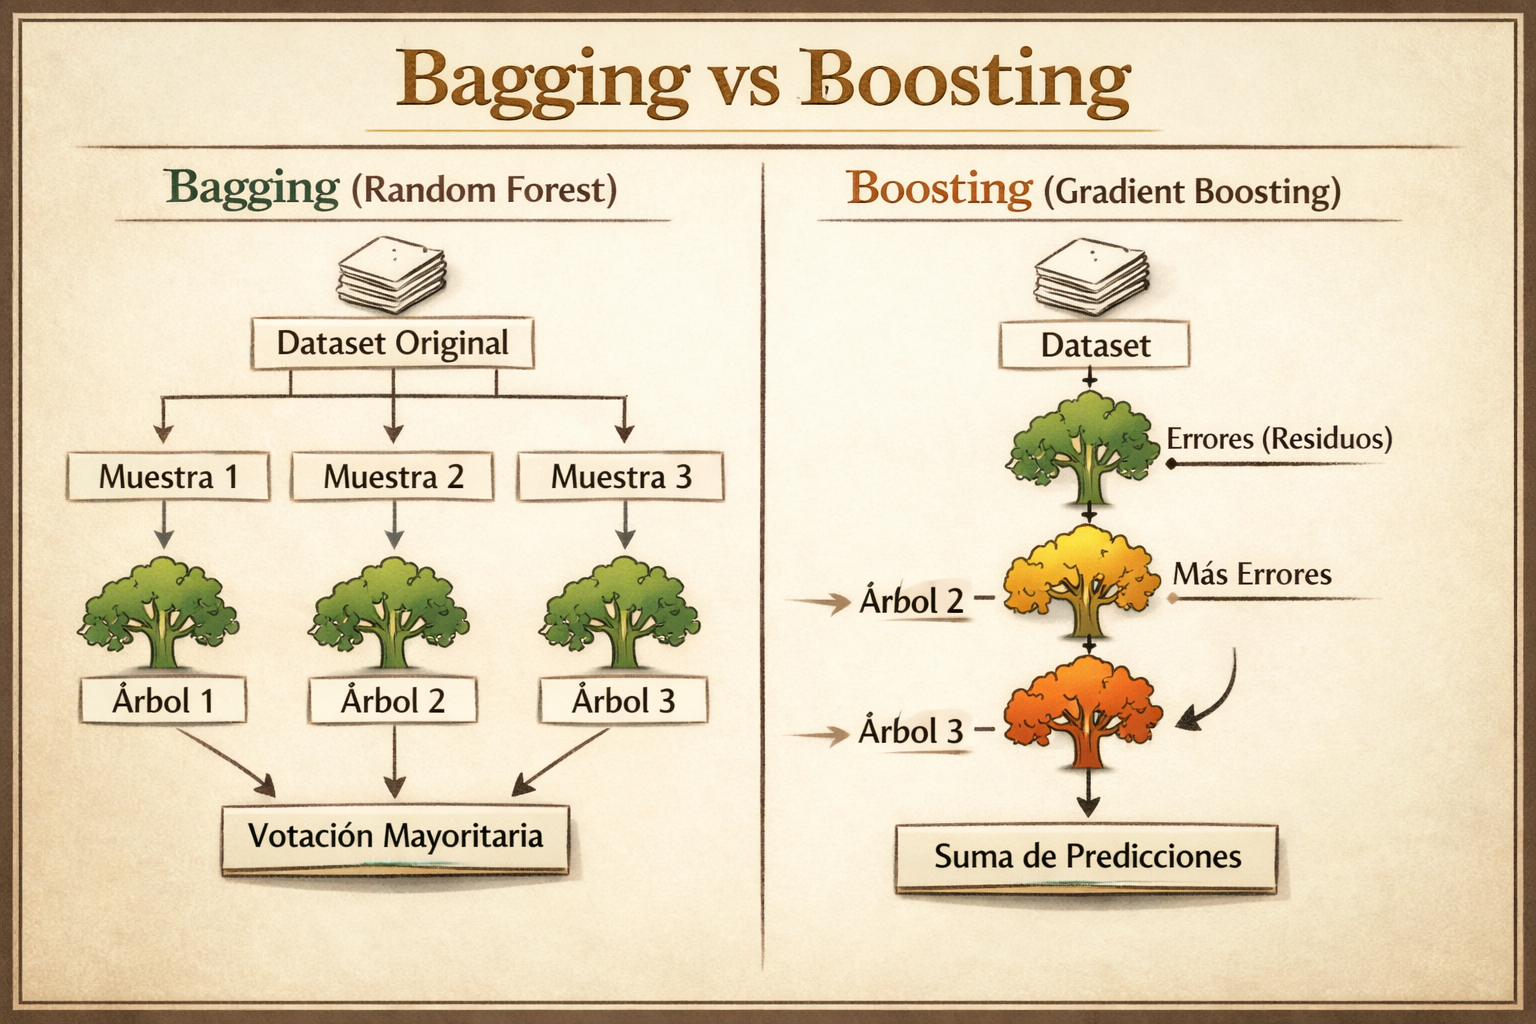

## Desarrollo e Implementación



Vamos a utilizar el **Stroke Prediction Dataset (ACV)**. Este dataset presenta un desafío de ingeniería masivo: **El Desbalance de Clases Severo**.



Dataset cargado exitosamente con 5110 filas y 12 columnas.


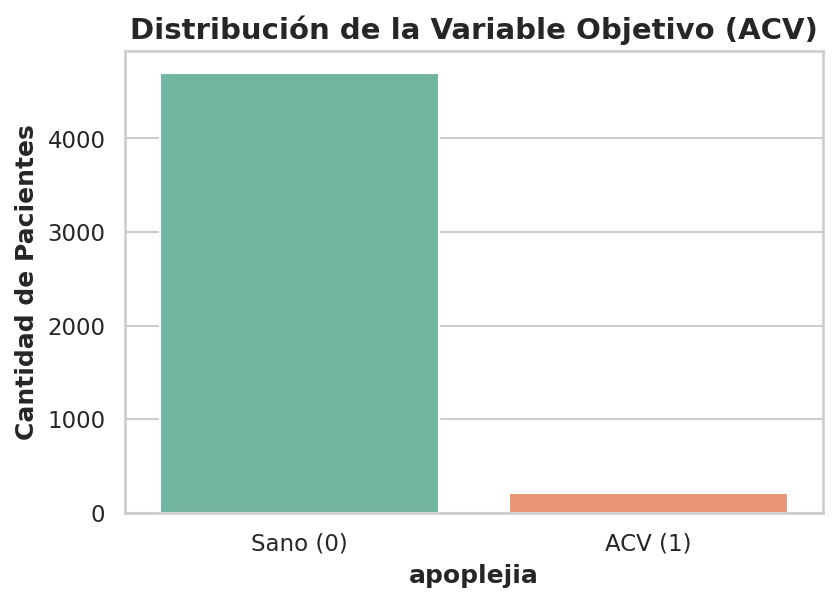

Pacientes con ACV: 4.26% del dataset.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# 1. Carga de datos
dataset_path = "datasets/acv/datos_acv.csv"
df = load_dataset(dataset_path)

# Limpieza rápida (Eliminamos nulos para enfocarnos en el algoritmo)
df = df.drop(columns=['id']).dropna()
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['apoplejia'])
y = df_encoded['apoplejia']

# 2. Analizamos el Desbalance
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.title("Distribución de la Variable Objetivo (ACV)")
plt.xticks([0, 1], ['Sano (0)', 'ACV (1)'])
plt.ylabel("Cantidad de Pacientes")
plt.show()

porcentaje_acv = (y.sum() / len(y)) * 100
print(f"Pacientes con ACV: {porcentaje_acv:.2f}% del dataset.")


Solo el $\sim 4.2\%$ de los pacientes sufrieron un ACV. Si un modelo "tonto" predice que *nadie* sufrirá un ACV, obtendrá un **95.8% de Accuracy**.

Por lo tanto, el *Accuracy* es una métrica inútil aquí. Evaluaremos nuestros modelos usando el **Recall** (Sensibilidad: de todos los que realmente tuvieron un ACV, ¿cuántos detectó el modelo?) y el **ROC-AUC** (Capacidad general de separar las clases).



### Entrenando los Ensambles



Vamos a entrenar un Random Forest y un Gradient Boosting.

*Nota de Ingeniería:* Los ensambles basados en árboles **no requieren escalado de variables**. Un árbol solo pregunta *"¿Edad > 50?"*; no le importa si la edad está en años o en milisegundos, el punto de corte será el mismo.



In [7]:
# División Train/Test (Usamos stratify para mantener el 4% de ACVs en ambos sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. Random Forest (Bagging)
# class_weight='balanced' penaliza fuertemente al modelo si se equivoca en la clase minoritaria (ACV)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 2. Gradient Boosting (Boosting)
# Nota: Scikit-Learn's GradientBoosting no soporta class_weight nativamente.
# En la industria usaríamos XGBoost o LightGBM (scale_pos_weight), pero aquí ajustamos el umbral luego.
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

# Predicciones (Probabilidades)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC Random Forest: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"ROC-AUC Gradient Boosting: {roc_auc_score(y_test, y_prob_gb):.4f}")

ROC-AUC Random Forest: 0.7657
ROC-AUC Gradient Boosting: 0.8003



Ambos modelos tienen un muy buen ROC-AUC (Gradient Boosting un poco mejor incluso, con $\sim 0.8$), lo que significa que ordenan muy bien a los pacientes de menor a mayor riesgo.



### El Problema del Umbral en Clases Desbalanceadas



Veamos qué pasa si usamos el umbral por defecto ($0.5$) para tomar la decisión final de quién está enfermo y quién no.



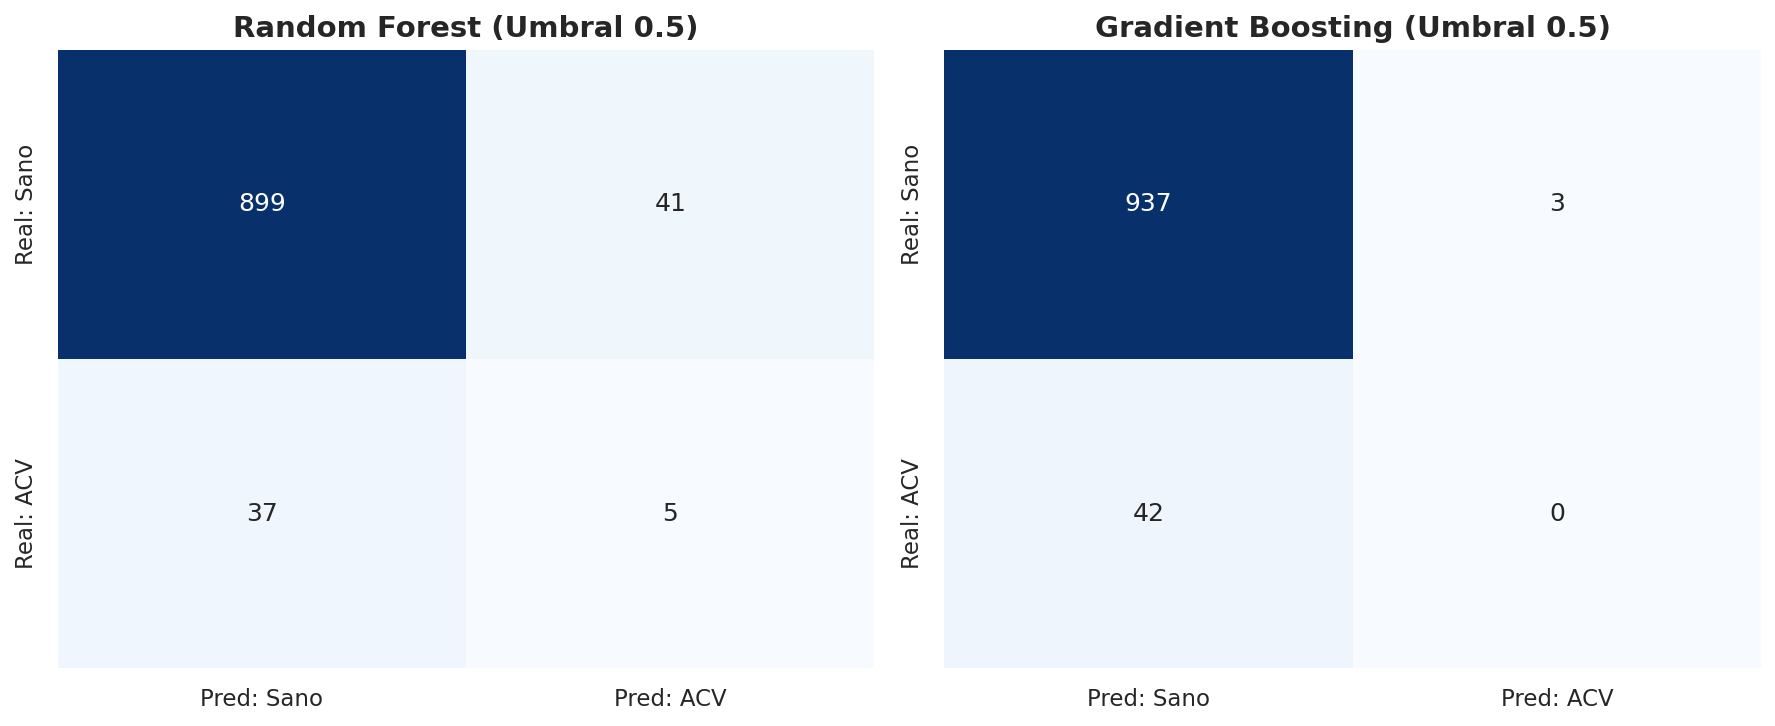

In [8]:
# Predicciones binarias con umbral 0.5
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# Función para graficar matrices de confusión
def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred: Sano', 'Pred: ACV'],
                yticklabels=['Real: Sano', 'Real: ACV'])
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_cm(y_test, y_pred_rf, "Random Forest (Umbral 0.5)", axes[0])
plot_cm(y_test, y_pred_gb, "Gradient Boosting (Umbral 0.5)", axes[1])
plt.tight_layout()
plt.show()

## Resultados y Discusión


Analizar las matrices de confusión con ojo clínico (entendiendo la gravedad de los errores en la vida):

1. **Gradient Boosting (Derecha):** ¡Es un desastre médico! De los 42 pacientes que realmente tuvieron un ACV (Fila inferior), el modelo NO detectó ni a 1. Los 42 fueron enviados a casa como "Sanos" (Falsos Negativos). ¿Por qué? Porque el modelo priorizó el *Accuracy* global y, como la clase ACV es tan rara, la probabilidad que asigna rara vez supera el 50%.
2. **Random Forest (Izquierda):** Lo hizo mucho mejor detectando ACVs (encontró a 5 de 42). Esto se debe a que le pasamos el parámetro `class_weight='balanced'`, obligando a los árboles a prestarle 20 veces más atención a un paciente con ACV que a uno sano durante el entrenamiento.



### Ingeniería del Umbral (Threshold Tuning)



Para arreglar el Gradient Boosting, no necesitamos reentrenarlo. Solo necesitamos bajar el umbral de decisión. Si el modelo está un 10% seguro de que el paciente tendrá un ACV, es suficiente para enviarlo a hacerse estudios preventivos.



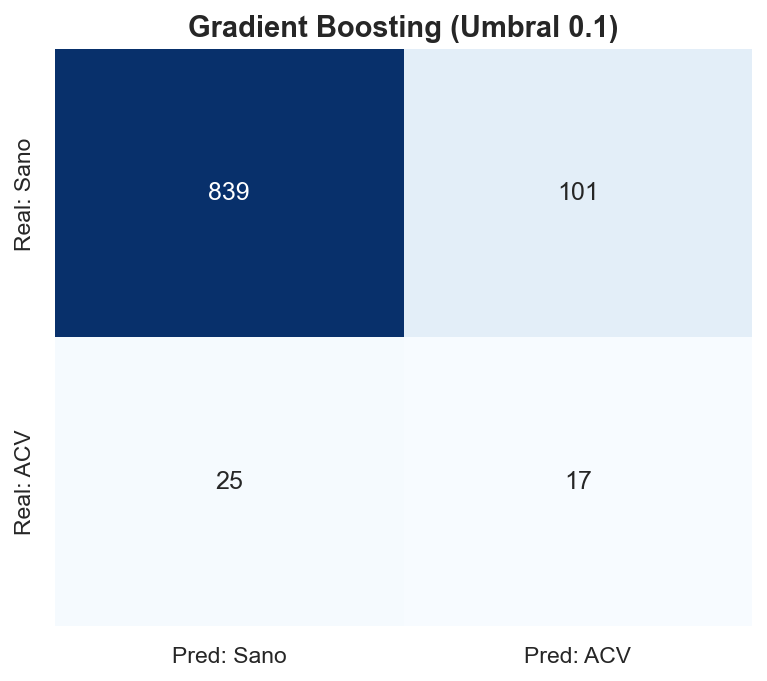

Class,Precision,Recall,F-score,Support
Sano,0.97,0.89,0.93,940
ACV,0.14,0.40,0.21,42
Avg.,0.94,0.87,0.90,982


In [6]:
# Bajamos el umbral a 0.10 (10% de probabilidad)
umbral_medico = 0.10
y_pred_gb_ajustado = (y_prob_gb >= umbral_medico).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
plot_cm(y_test, y_pred_gb_ajustado, f"Gradient Boosting (Umbral {umbral_medico})", ax)
plt.show()

from utils.plots import render_classification_report
render_classification_report(y_test, y_pred_gb_ajustado, classes=["Sano", "ACV"],
                            caption="Reporte Médico - Gradient Boosting Ajustado",
                            show_support=True)

¡Ahora sí! Detectados 17 de los 42 pacientes en riesgo (Recall del 43%). A cambio, asustamos a 101 pacientes sanos (Falsos Positivos), pero en medicina preventiva, un falso positivo (hacer un examen extra) es infinitamente preferible a un falso negativo (ignorar un ACV inminente).

## Conexiones y Próximos Pasos



Los ensambles de árboles (especialmente implementaciones modernas como XGBoost o LightGBM) son el estándar absoluto de la industria para datos tabulares. Son robustos, no requieren escalado y manejan relaciones no lineales automáticamente.

Sin embargo, en este notebook hicimos trampa: eliminamos las filas con valores nulos (IMC) antes de dividir los datos. En el mundo real, debemos imputar esos valores.

- ➡️ **Siguiente:** En el notebook [Pipelines y Prevención de Leakage](09_pipelines_y_prevencion_leakage.ipynb), aprendemos a construir un flujo de trabajo profesional. Embutimos la imputación de nulos, la codificación de variables categóricas y el modelo Random Forest en un único objeto `Pipeline`, garantizando que nuestro sistema sea a prueba de balas para producción.
- 🔄 **Relacionado:** Si se quiere entender cómo optimizar los hiperparámetros de este Random Forest (ej. `n_estimators` o `max_depth`), repasar el notebook [Optimización de Hiperparámetros](07_optimizacion_hiperparametros_y_cv.ipynb).



## Referencias


1. Breiman, L. (2001). *Random forests*. Machine learning, 45(1), 5-32.
2. Friedman, J. H. (2001). *Greedy function approximation: a gradient boosting machine*. Annals of statistics, 1189-1232.
3. [Scikit-Learn: Ensemble methods](https://scikit-learn.org/stable/modules/ensemble.html)

---


## Entorno de Ejecución


In [10]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
